# Lecture 21 notebook: Grid search, autograd, and optimization in PyTorch

In this notebook, we will study a **two-parameter parameter-estimation problem**.

Our goals are:

1. build a simple two-parameter model,
2. fit the model to observed data using **grid search**,
3. visualize the **loss surface** in two dimensions,
4. understand why grid search becomes difficult when the number of parameters grows,
5. introduce **automatic differentiation (autograd)** in PyTorch,
6. solve the same fitting problem using a PyTorch optimizer.

We will use a simple ODE model

$$
y'(t) = -a\,y(t) + b,
$$

with two unknown parameters:

- $a$: controls how strongly the solution decays,
- $b$: adds a constant forcing term.

We will assume that we have measured noisy values of $y(t)$ at several times and want to estimate the best pair $(a,b)$.

## 1. Import the libraries we need

In the next cell, we import:

- `torch` for tensor computations,
- `matplotlib.pyplot` for plotting.

We also set a random seed so that results are reproducible. That means if someone else runs the notebook, they will get the same randomly generated noise.

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(7)

## 2. Create the observed data

In this cell, we create the data that we want to fit.

We choose a set of observation times

$$
t_0, t_1, \dots, t_N
$$

and then specify noisy measurements

$$
y_0^{obs}, y_1^{obs}, \dots, y_N^{obs}.
$$

You can think of these values as measurements collected from an experiment.

We will use the same data values that were used in the lecture slides.  
The times are equally spaced and the observed values decrease over time, which is consistent with a decaying process.

Important ideas:

- `t_obs` stores the measurement times,
- `y_obs` stores the measured values,
- both are stored as **PyTorch tensors**,
- we use `dtype=torch.float32` because optimization and autograd are normally done with floating-point tensors.

In [2]:
t_obs = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=torch.float32)
y_obs = torch.tensor([10.0, 8.9, 7.8, 7.0, 6.3, 5.9, 5.5, 5.3, 5.1], dtype=torch.float32)

t_obs, y_obs

(tensor([0., 1., 2., 3., 4., 5., 6., 7., 8.]),
 tensor([10.0000,  8.9000,  7.8000,  7.0000,  6.3000,  5.9000,  5.5000,  5.3000,
          5.1000]))

## 3. Plot the observed data

The next cell makes a scatter plot of the measured data.

This plot is important because parameter estimation always starts with the question:

> What kind of pattern are we trying to explain?

Here:

- the horizontal axis is time $t$,
- the vertical axis is the observed value $y^{obs}$,
- we only plot points, because these are measurements, not an exact continuous curve.

Notice that the data decrease quickly at first and then flatten a bit.  
That suggests that a model with both decay and a constant forcing term may be reasonable.

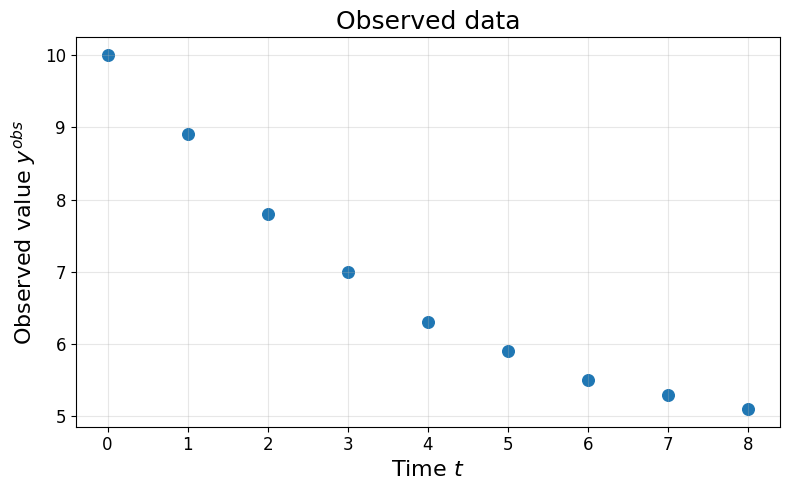

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(t_obs, y_obs, s=70)
plt.xlabel("Time $t$", fontsize=16)
plt.ylabel("Observed value $y^{obs}$", fontsize=16)
plt.title("Observed data", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Define the two-parameter ODE model and solve it with Forward Euler

We now define the model

$$
y'(t) = -a\,y(t) + b.
$$

To compare this model with data, we need to compute model predictions at the observation times.  
We will do that numerically using the **Forward Euler method**.

If the time step is $\Delta t$, Forward Euler gives

$$
y_{n+1} = y_n + \Delta t\,(-a\,y_n + b).
$$

In the next cell, we write a function called `forward_euler_model(a, b, t_obs, y0)`.

What the function does:

- takes parameter values $a$ and $b$,
- starts from the initial value $y(0)=y_0$,
- steps forward in time using Forward Euler,
- returns the predicted values at all observation times.

Important implementation details:

- `a` and `b` will be PyTorch tensors,
- that matters later because PyTorch can track operations on tensors and differentiate through them,
- the code is written in a way that works both for ordinary tensor computations and for autograd-based optimization.

In [4]:
def forward_euler_model(a, b, t_obs, y0):
    y_values = [y0]

    dt = t_obs[1] - t_obs[0]

    for _ in range(len(t_obs) - 1):
        y_next = y_values[-1] + dt * (-a * y_values[-1] + b)
        y_values.append(y_next)

    return torch.stack(y_values)

## 5. Test the model for one guess of $(a,b)$

Before we do any fitting, it is always a good idea to test the solver with a single parameter guess.

In the next cell:

- we choose one trial value for $a$,
- one trial value for $b$,
- compute the predicted solution,
- plot the prediction together with the observed data.

This helps us answer a basic question:

> Does the model move in the right general direction?

Even if the fit is not perfect yet, a trial plot helps build intuition about what the parameters do.

Rough interpretation:

- increasing $a$ usually makes the decay stronger,
- increasing $b$ usually pushes the solution upward.

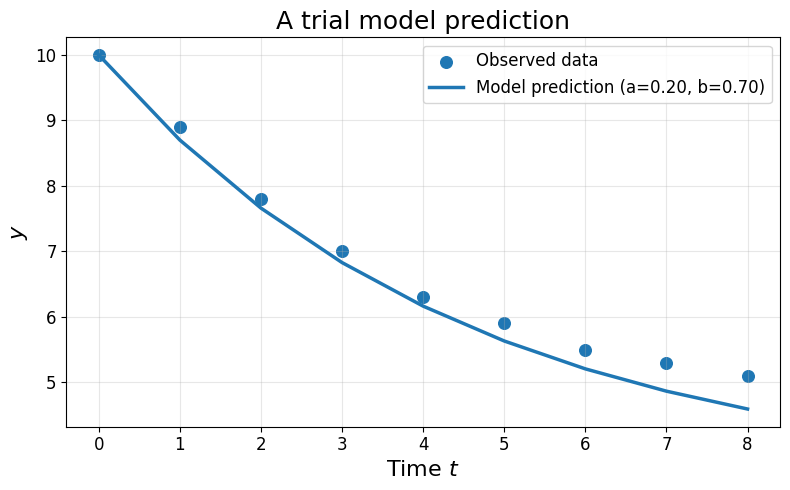

In [5]:
a_test = torch.tensor(0.20)
b_test = torch.tensor(0.70)

y_pred_test = forward_euler_model(a_test, b_test, t_obs, y_obs[0])

plt.figure(figsize=(8, 5))
plt.scatter(t_obs, y_obs, s=70, label="Observed data")
plt.plot(t_obs, y_pred_test, linewidth=2.5, label=f"Model prediction (a={a_test:.2f}, b={b_test:.2f})")
plt.xlabel("Time $t$", fontsize=16)
plt.ylabel("$y$", fontsize=16)
plt.title("A trial model prediction", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 6. Define the loss function

To decide whether one parameter pair $(a,b)$ is good or bad, we need a numerical measure of mismatch.

We will use the **least-squares loss**:

$$
L(a,b) = \sum_{i=0}^{N} \left(y_i^{pred}(a,b) - y_i^{obs}\right)^2.
$$

Interpretation:

- for each time point, compute the error,
- square the error so that positive and negative errors do not cancel,
- add all squared errors together.

If the prediction matches the data well, the loss is small.  
If the prediction is poor, the loss is large.

In the next cell, we define a function `loss_fn(a, b)` that:

1. solves the ODE numerically,
2. compares the predicted values with the observed values,
3. returns the scalar loss.

Because we use PyTorch operations throughout, this loss can later be differentiated automatically.

In [6]:
def loss_fn(a, b, t_obs, y_obs):
    y_pred = forward_euler_model(a, b, t_obs, y_obs[0])
    return torch.sum((y_pred - y_obs) ** 2)

loss_fn(a_test, b_test, t_obs, y_obs)

tensor(0.7191)

## 7. Grid search in two dimensions

Now we do the first main task of the notebook: **2D grid search**.

The idea is simple:

- choose many candidate values for $a$,
- choose many candidate values for $b$,
- try every pair $(a,b)$ on a rectangular grid,
- compute the loss at each grid point,
- keep the pair with the smallest loss.

This is very direct and easy to understand.  
It is a good first method when there are only one or two parameters.

In the next cell:

- `a_vals` is a grid of possible $a$ values,
- `b_vals` is a grid of possible $b$ values,
- `loss_grid[i, j]` will store the loss for one specific pair.

Even though this is called grid search, the actual loss evaluation still uses our PyTorch solver and PyTorch loss function.

In [7]:
a_vals = torch.linspace(0.05, 0.35, 121)
b_vals = torch.linspace(0.00, 1.80, 121)

loss_grid = torch.zeros((len(b_vals), len(a_vals)), dtype=torch.float32)

for i, b in enumerate(b_vals):
    for j, a in enumerate(a_vals):
        loss_grid[i, j] = loss_fn(a, b, t_obs, y_obs)

min_flat_index = torch.argmin(loss_grid)
min_index = torch.unravel_index(min_flat_index, loss_grid.shape)

best_b_grid = b_vals[min_index[0]]
best_a_grid = a_vals[min_index[1]]
best_loss_grid = loss_grid[min_index]

print(f"Best a (grid search): {best_a_grid:.4f}")
print(f"Best b (grid search): {best_b_grid:.4f}")
print(f"Best loss (grid search): {best_loss_grid:.4f}")

Best a (grid search): 0.2150
Best b (grid search): 0.9000
Best loss (grid search): 0.0426


## 8. Plot the loss surface as a heatmap / contour plot

Now we visualize the result of the grid search.

This is one of the most important geometric ideas in the lecture.

Since the loss depends on two parameters, it is a function

$$
L(a,b).
$$

That means:

- in one parameter, the loss is a **curve**,
- in two parameters, the loss is a **surface**.

A contour plot shows curves of equal loss.  
A heatmap shows how the loss value changes across parameter space using color.

In the next cell:

- the horizontal axis is parameter $a$,
- the vertical axis is parameter $b$,
- the color represents the value of the loss,
- the star marks the minimum found by grid search.

When you look at this plot, imagine hiking on a landscape:

- bright/high regions correspond to large loss,
- dark/low regions correspond to small loss,
- the optimizer's goal is to move downhill toward the minimum.

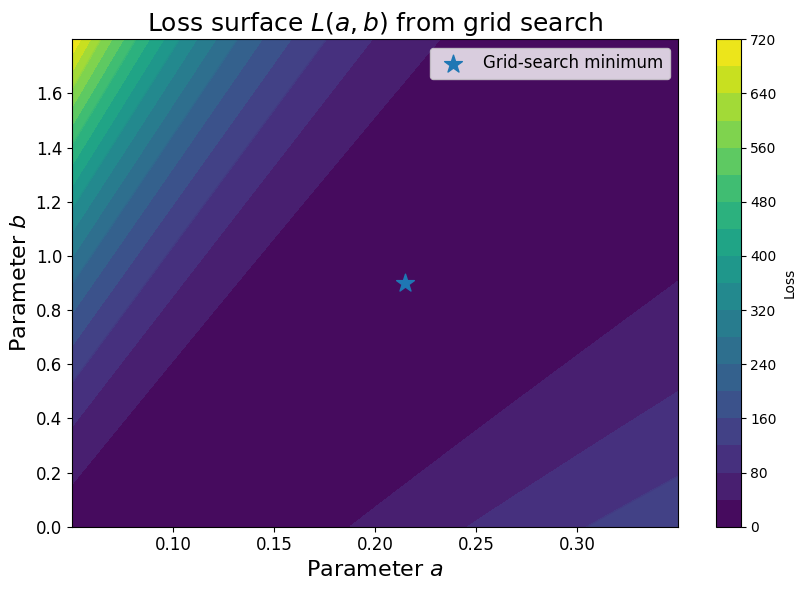

In [8]:
A_grid, B_grid = torch.meshgrid(a_vals, b_vals, indexing="xy")

plt.figure(figsize=(8.5, 6))
cont = plt.contourf(A_grid, B_grid, loss_grid, levels=20)
plt.contour(A_grid, B_grid, loss_grid, levels=12, linewidths=0.8)
plt.scatter(best_a_grid, best_b_grid, s=180, marker="*", label="Grid-search minimum")
plt.xlabel("Parameter $a$", fontsize=16)
plt.ylabel("Parameter $b$", fontsize=16)
plt.title("Loss surface $L(a,b)$ from grid search", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.colorbar(cont, label="Loss")
plt.tight_layout()
plt.show()

## 9. Plot the best-fit model from grid search

A minimum on the loss surface is useful, but we should always go back and ask:

> What does the actual fitted curve look like?

In the next cell, we take the best parameters from grid search and:

- solve the model one more time,
- plot the best-fit prediction,
- compare it directly with the observed data.

This closes the loop between:

- parameter space $(a,b)$,
- loss function $L(a,b)$,
- predicted physical/model behavior $y(t)$.

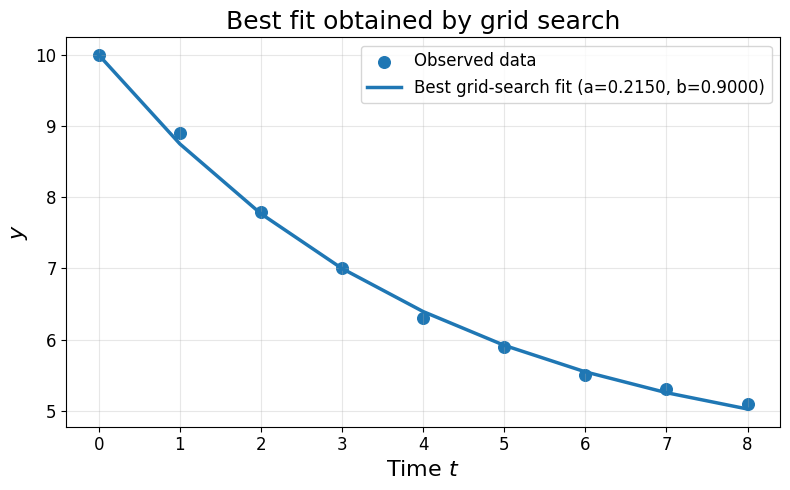

In [9]:
y_pred_grid_best = forward_euler_model(best_a_grid, best_b_grid, t_obs, y_obs[0])

plt.figure(figsize=(8, 5))
plt.scatter(t_obs, y_obs, s=70, label="Observed data")
plt.plot(t_obs, y_pred_grid_best, linewidth=2.5, label=f"Best grid-search fit (a={best_a_grid:.4f}, b={best_b_grid:.4f})")
plt.xlabel("Time $t$", fontsize=16)
plt.ylabel("$y$", fontsize=16)
plt.title("Best fit obtained by grid search", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 10. Why grid search becomes difficult in higher dimensions

Grid search is easy to understand, but it does not scale well.

Suppose we use:

- 121 trial values per parameter.

Then the number of grid points is:

- 1 parameter: $121$ points,
- 2 parameters: $121^2 = 14,\!641$ points,
- 3 parameters: $121^3 = 1,\!771,\!561$ points,
- 4 parameters: $121^4$ points,
- 5 parameters: $121^5$ points, which is enormous.

This rapid growth is part of what people often call the **curse of dimensionality**.

The key message is:

- grid search is fine for one or two parameters,
- but for many parameters, it becomes too expensive,
- so we need a smarter method that uses local slope information.

That idea leads naturally to **gradients** and **automatic differentiation**.

In [10]:
points_per_parameter = torch.tensor(121)

for num_params in [1, 2, 3, 4, 5]:
    total_points = points_per_parameter ** num_params
    print(f"{num_params} parameters: {int(total_points.item()):,} grid points")

1 parameters: 121 grid points
2 parameters: 14,641 grid points
3 parameters: 1,771,561 grid points
4 parameters: 214,358,881 grid points
5 parameters: 25,937,424,601 grid points


## 11. Introducing autograd in PyTorch

PyTorch can automatically compute derivatives for us.  
This feature is called **automatic differentiation**, or **autograd**.

The basic idea is:

1. create a tensor and tell PyTorch that it should track gradients,
2. compute some quantity from that tensor,
3. call `.backward()` on that quantity,
4. PyTorch fills in the derivative in the `.grad` field.

We first show this idea in a tiny example before applying it to the full parameter-estimation problem.

In the next cell:

- `x` is a tensor with `requires_grad=True`,
- that tells PyTorch: "please remember the computations involving this variable",
- we define a simple scalar function
  $$
  f(x) = (x-3)^2,
  $$
- then call `f.backward()`.

From calculus, we know that

$$
\frac{df}{dx} = 2(x-3).
$$

At $x=5$, the derivative should be $4$.  
PyTorch should recover exactly that.

In [11]:
x = torch.tensor(5.0, requires_grad=True)
f = (x - 3.0) ** 2
f.backward()

print("x =", x.item())
print("f(x) =", f.item())
print("df/dx =", x.grad.item())

x = 5.0
f(x) = 4.0
df/dx = 4.0


## 12. What `requires_grad=True` means

Before we use autograd for our model parameters, let us pause and interpret the previous example carefully.

When we wrote

```python
x = torch.tensor(5.0, requires_grad=True)
```

we were telling PyTorch:

> "This quantity is a variable I may want to differentiate with respect to."

So PyTorch keeps track of how later computations depend on `x`.

In our parameter-estimation problem, the unknown parameters $a$ and $b$ play exactly this role.  
They are not fixed constants anymore.  
They are variables we want to adjust in order to reduce the loss.

So later we will write something like

```python
a = torch.tensor(..., requires_grad=True)
b = torch.tensor(..., requires_grad=True)
```

and then let PyTorch compute:

- $\partial L / \partial a$,
- $\partial L / \partial b$.

That is the gradient information needed for optimization.

## 13. Use autograd to compute the gradient of the loss at one parameter guess

Now we apply autograd to the actual fitting problem.

In the next cell we do the following:

1. create trial values for `a` and `b`,
2. set `requires_grad=True` for both,
3. compute the loss $L(a,b)$,
4. call `loss.backward()`.

After that, PyTorch stores:

- `a.grad` as $\partial L / \partial a$,
- `b.grad` as $\partial L / \partial b$.

This is a major conceptual leap:

- with grid search, we checked many points one by one,
- with autograd, we can stand at one point and ask:
  > In which direction should I move to reduce the loss?

That direction comes from the gradient.

In [12]:
a_trial = torch.tensor(0.15, dtype=torch.float32, requires_grad=True)
b_trial = torch.tensor(0.70, dtype=torch.float32, requires_grad=True)

loss_trial = loss_fn(a_trial, b_trial, t_obs, y_obs)
loss_trial.backward()

print("Loss =", loss_trial.item())
print("dL/da =", a_trial.grad.item())
print("dL/db =", b_trial.grad.item())

Loss = 7.690718650817871
dL/da = -440.0299987792969
dL/db = 53.277530670166016


## 14. Interpreting `loss.backward()` in plain language

This is one of the most important ideas in the entire notebook.

When we call

```python
loss.backward()
```

PyTorch works backward through all the computations that produced the loss.

In our case, the chain of computation is roughly:

1. start with parameters $a$ and $b$,
2. use them inside the Forward Euler solver,
3. produce predicted values $y^{pred}$,
4. compare predictions with observed data,
5. compute the scalar loss.

Calling `loss.backward()` tells PyTorch:

> "Please use the chain rule and compute how sensitive the final loss is to each parameter."

So after `loss.backward()`:

- `a.grad` contains $\partial L / \partial a$,
- `b.grad` contains $\partial L / \partial b$.

Accessible interpretation for basic calculus students:

- if `a.grad` is large and positive, increasing $a$ would increase the loss, so we likely want to move $a$ downward,
- if `a.grad` is negative, increasing $a$ would decrease the loss, so we likely want to move $a$ upward,
- similarly for `b.grad`.

So the gradients are not the answer themselves.  
They are **directions telling us how to improve the answer**.

## 15. Solving the problem automatically with a PyTorch optimizer

Now we let PyTorch repeatedly update the parameters for us.

We will use the optimizer `torch.optim.SGD`, which stands for **stochastic gradient descent**.  
Here we are using it in a simple full-batch way, so you can think of it as ordinary gradient descent.

The optimizer needs to know:

- which parameters it is allowed to change,
- the learning rate.

We will initialize `a_opt` and `b_opt` away from the optimum on purpose so we can watch the optimizer move them.

In the next cell, we create:

- `a_opt` and `b_opt` as trainable tensors,
- an SGD optimizer,
- lists to store the optimization history.

Storing the history is useful because later we can plot the path taken in parameter space.

In [13]:
a_opt = torch.tensor(0.20, dtype=torch.float32, requires_grad=True)
b_opt = torch.tensor(0.80, dtype=torch.float32, requires_grad=True)

optimizer = torch.optim.SGD([a_opt, b_opt], lr=0.0002)

## 16. The three key optimizer commands: `zero_grad()`, `backward()`, and `step()`

The next cell runs the optimization loop.  
Before running it, it is worth understanding the three most important commands very clearly.

### (a) `optimizer.zero_grad()`

This clears out old gradient values.

Why is that necessary?

PyTorch **accumulates** gradients by default.  
That means if you do `.backward()` many times, the new gradients get added onto the old ones unless you erase them first.

So at the start of each optimization step, we write:

```python
optimizer.zero_grad()
```

Meaning:

> "Forget the old slope information. We are about to compute fresh gradients at the current point."

### (b) `loss.backward()`

This computes the current gradients using the chain rule.

Meaning:

> "At the current values of $a$ and $b$, tell me how the loss changes if I move each parameter a little."

After this line, PyTorch has filled in:

- `a_opt.grad`,
- `b_opt.grad`.

### (c) `optimizer.step()`

This tells the optimizer to actually update the parameters.

For gradient descent, the idea is

$$
\theta_{k+1} = \theta_{k} - \eta \nabla L.
$$

So in plain language, `optimizer.step()` means:

> "Use the gradients you just computed, and move the parameters a little in the downhill direction."

Putting the three together, each iteration does:

1. erase old gradients,
2. compute fresh gradients,
3. take one downhill step.

That is the basic rhythm of gradient-based optimization in PyTorch.

In [14]:
history_a = []
history_b = []
history_loss = []
num_iterations = 10000

for k in range(num_iterations):
    history_a.append(a_opt.detach().clone())
    history_b.append(b_opt.detach().clone())

    optimizer.zero_grad()
    loss = loss_fn(a_opt, b_opt, t_obs, y_obs)

    loss.backward()
    optimizer.step()

    # with torch.no_grad():
    #     a_opt.clamp_(0.01, 0.50)
    #     b_opt.clamp_(0.01, 2.00)

    history_loss.append(loss.detach().clone())

    if (k + 1) % 100 == 0 or k == 0:
        print(f"Iter {k:4d}:  a = {a_opt.item():.6f},  b = {b_opt.item():.6f},  loss = {loss.item():.6f}")

history_a = torch.stack(history_a)
history_b = torch.stack(history_b)
history_loss = torch.stack(history_loss)


Iter    0:  a = 0.202010,  b = 0.799780,  loss = 0.061754
Iter   99:  a = 0.201813,  b = 0.804595,  loss = 0.054648
Iter  199:  a = 0.202425,  b = 0.809142,  loss = 0.053595
Iter  299:  a = 0.203011,  b = 0.813492,  loss = 0.052631
Iter  399:  a = 0.203571,  b = 0.817655,  loss = 0.051748
Iter  499:  a = 0.204107,  b = 0.821639,  loss = 0.050939
Iter  599:  a = 0.204621,  b = 0.825451,  loss = 0.050199
Iter  699:  a = 0.205112,  b = 0.829099,  loss = 0.049521
Iter  799:  a = 0.205582,  b = 0.832591,  loss = 0.048899
Iter  899:  a = 0.206032,  b = 0.835933,  loss = 0.048330
Iter  999:  a = 0.206463,  b = 0.839132,  loss = 0.047809
Iter 1099:  a = 0.206876,  b = 0.842194,  loss = 0.047331
Iter 1199:  a = 0.207270,  b = 0.845125,  loss = 0.046894
Iter 1299:  a = 0.207648,  b = 0.847930,  loss = 0.046493
Iter 1399:  a = 0.208010,  b = 0.850616,  loss = 0.046125
Iter 1499:  a = 0.208357,  b = 0.853187,  loss = 0.045788
Iter 1599:  a = 0.208688,  b = 0.855649,  loss = 0.045480
Iter 1699:  a 

## 17. Plot the loss value during optimization

Now we check whether the optimizer actually improved the fit.

The next plot shows the loss value versus iteration number.

What to look for:

- if the curve goes downward, the optimizer is making progress,
- if it flattens out, the optimizer may be approaching a minimum,
- if it oscillates wildly or increases, the learning rate may be too large.

This plot is useful because optimization is not only about the final answer.  
It is also about the **process** of getting there.

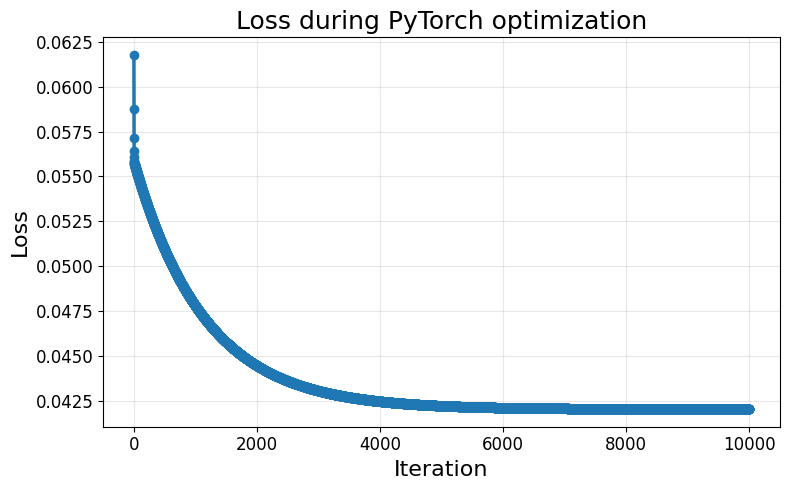

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history_loss, '-o', linewidth=2.5)
plt.xlabel("Iteration", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.title("Loss during PyTorch optimization", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 18. Compare the optimized parameters with the grid-search result

Now we compare the two approaches:

- **grid search**,
- **PyTorch optimization**.

This is a very useful check.  
If both methods give similar parameter values, that increases our confidence that the optimizer is converging to the same low-loss region found by brute force.

The next cell prints:

- the best pair from grid search,
- the best pair from gradient-based optimization.

In [17]:
print("Grid search:")
print("  a =", best_a_grid.item())
print("  b =", best_b_grid.item())
print("  loss =", best_loss_grid.item())

print("\nPyTorch optimization:")
print("  a =", a_opt.item())
print("  b =", b_opt.item())
print("  loss =", history_loss[-1].item())

Grid search:
  a = 0.2150000035762787
  b = 0.8999999761581421
  loss = 0.04263616353273392

PyTorch optimization:
  a = 0.21600553393363953
  b = 0.9099079370498657
  loss = 0.04207005351781845


## 19. Plot the fitted curve from PyTorch optimization

In the next cell, we use the optimized values of $a$ and $b$ to generate a final model prediction.

Then we compare that prediction with the observed data.

This is the main practical outcome of the notebook:

- we started with unknown parameters,
- we used data to estimate them,
- now we can produce a best-fit model curve.

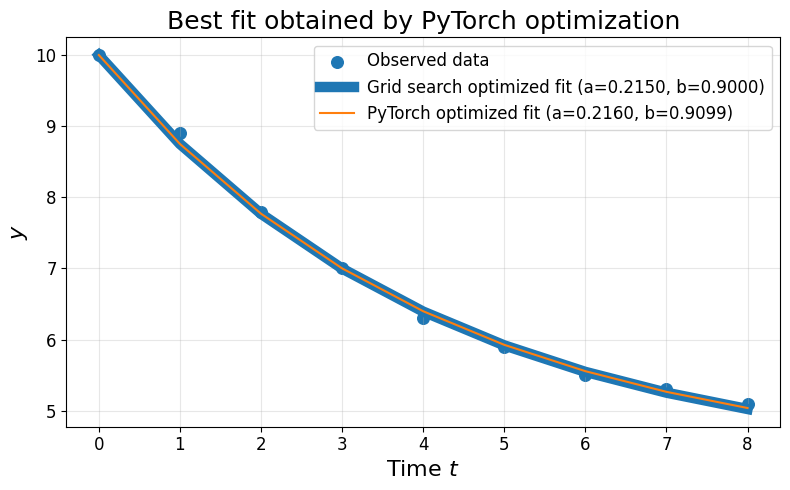

In [25]:
y_pred_opt = forward_euler_model(a_opt.detach(), b_opt.detach(), t_obs, y_obs[0])

plt.figure(figsize=(8, 5))
plt.scatter(t_obs, y_obs, s=70, label="Observed data")
plt.plot(t_obs, y_pred_grid_best, linewidth=7.5, label=f"Grid search optimized fit (a={best_a_grid.item():.4f}, b={best_b_grid.item():.4f})")
plt.plot(t_obs, y_pred_opt, linewidth=1.5, label=f"PyTorch optimized fit (a={a_opt.item():.4f}, b={b_opt.item():.4f})")
plt.xlabel("Time $t$", fontsize=16)
plt.ylabel("$y$", fontsize=16)
plt.title("Best fit obtained by PyTorch optimization", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 20. Plot the optimization path on top of the 2D loss contour

One of the best geometric pictures in optimization is to show the parameter path directly on the loss contour plot.

The next cell overlays the optimization history on top of the contour plot of $L(a,b)$.

This shows the sequence

$$
(a_0,b_0), (a_1,b_1), (a_2,b_2), \dots
$$

as it moves through parameter space.

Interpretation:

- each point is one iteration,
- the path shows how the optimizer updates the parameters,
- ideally the path moves toward the minimum.

This is the 2D analogue of moving downhill on a surface.

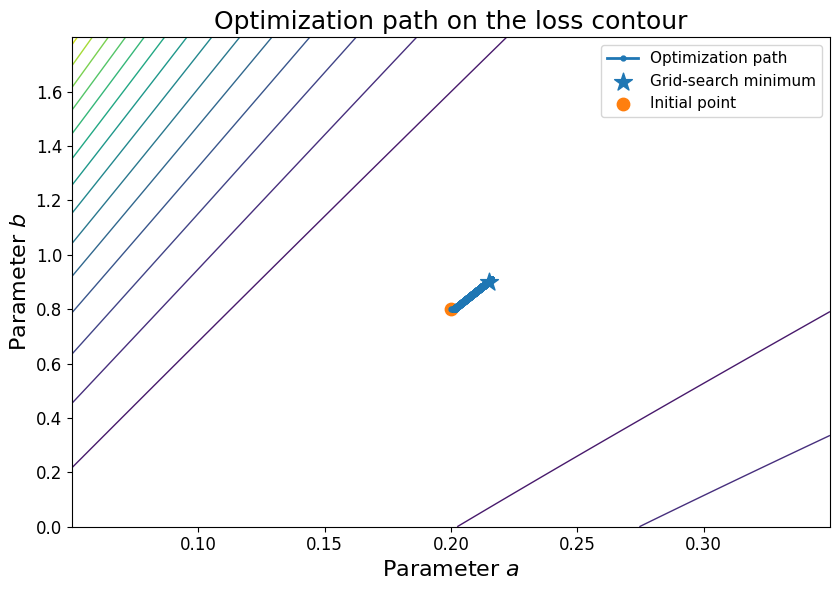

In [26]:
plt.figure(figsize=(8.5, 6))
plt.contour(A_grid, B_grid, loss_grid, levels=15, linewidths=1.0)
plt.plot(history_a, history_b, marker='o', markersize=3.5, linewidth=2.0, label="Optimization path")
plt.scatter(best_a_grid, best_b_grid, s=180, marker='*', label="Grid-search minimum")
plt.scatter(history_a[0], history_b[0], s=80, label="Initial point")
plt.xlabel("Parameter $a$", fontsize=16)
plt.ylabel("Parameter $b$", fontsize=16)
plt.title("Optimization path on the loss contour", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 21. Final summary

What we did in this notebook:

### Part 1: Two-parameter grid search
We defined a two-parameter model and evaluated the loss on a grid of $(a,b)$ values.  
This let us visualize the loss surface directly and find a minimum by brute force.

### Part 2: PyTorch autograd
We introduced `requires_grad=True` and showed that PyTorch can automatically compute derivatives of a scalar loss with respect to parameters.

### Part 3: PyTorch optimization
We used:

- `optimizer.zero_grad()`
- `loss.backward()`
- `optimizer.step()`

to iteratively reduce the loss and estimate the parameters.

### Main conceptual lesson
Grid search is easy to understand, but it becomes expensive in higher dimensions.  
Gradient-based optimization is much more scalable because it uses **local derivative information** to decide which direction to move.

This is why autograd and optimization are central tools in machine learning, inverse problems, and scientific computing.